In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import torch

from src.config import SEED
from src.transfer import build_feature_extractor, build_fine_tuner, train_transfer

torch.manual_seed(SEED)

# Transfer Learning con ResNet50
## Fase 4 - Feature Extraction y Fine-tuning

En vez de entrenar una red desde cero como la CNN, se aprovechó **ResNet50 preentrenada en ImageNet**: una red que ya aprendió a reconocer bordes, texturas y estructuras visuales complejas en 1.2 millones de imágenes.

Las imágenes fueron normalizadas con las estadísticas de ImageNet (media y desvío estándar) durante el preprocesamiento en `src/data.py`, para así poder utilizar ResNet50 para hacer transfer learning: dado que ResNet50 fue entrenada con esos valores, es necesario que los datos de entrada estén en el mismo rango.

Comparamos dos estrategias:

| Estrategia | Qué se entrena | LR | Parámetros entrenables |
|---|---|---|---|
| **Feature extraction** | Solo clasificador (fully connected) | 1e-3 | aprox 2049 |
| **Fine-tuning** | layer4 + clasificador | 1e-4 | aprox 15M |

**¿Por qué fine-tuning debería ser mejor que Feature extraction?**  
Detectar imágenes IA requiere reconocer artefactos de difusión y texturas sintéticas que no existen en ImageNet. Feature extraction usa los features genéricos tal como vienen, mientras que fine-tuning adapta las capas más profundas a nuestra tarea específica.

In [2]:
model_fe = build_feature_extractor()

total = sum(p.numel() for p in model_fe.parameters())
trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {trainable:,}  ({100*trainable/total:.1f}%)")

Parámetros totales:      23,510,081
Parámetros entrenables:  2,049  (0.0%)


## 1. Feature Extraction

Dispositivo: cuda


Epoch   1/50  train_loss=0.4192  val_loss=0.3563  val_acc=0.8465


Epoch   2/50  train_loss=0.3378  val_loss=0.3179  val_acc=0.8718


Epoch   3/50  train_loss=0.3169  val_loss=0.3107  val_acc=0.8698


Epoch   4/50  train_loss=0.3053  val_loss=0.2964  val_acc=0.8788


...

Epoch  20/50  train_loss=0.2815  val_loss=0.2810  val_acc=0.8855


Epoch  21/50  train_loss=0.2806  val_loss=0.2787  val_acc=0.8848


Epoch  22/50  train_loss=0.2796  val_loss=0.2792  val_acc=0.8860


Epoch  23/50  train_loss=0.2803  val_loss=0.2832  val_acc=0.8830


Early stopping en epoch 23.

Mejor val_loss: 0.2760


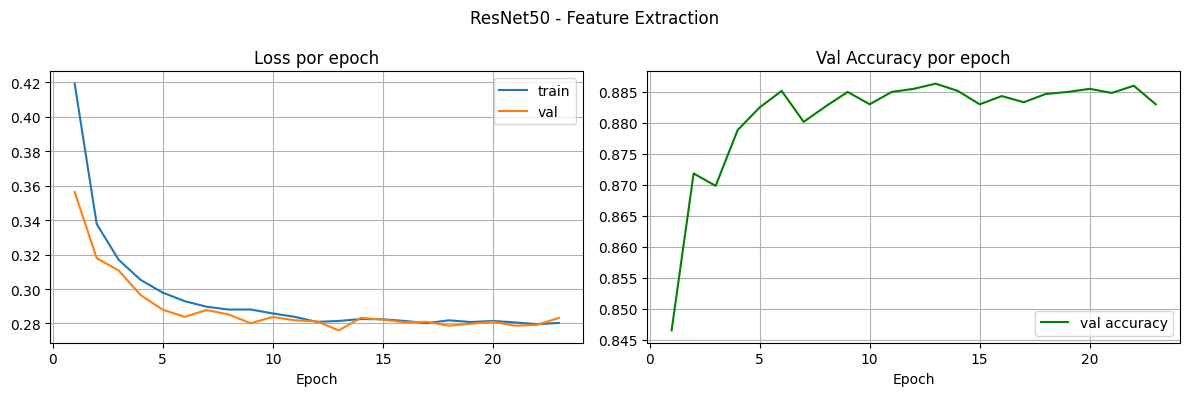

In [3]:
historial_fe = train_transfer(model_fe, save_name="fe")

## 2. Fine-tuning

Partiendo del mismo ResNet50 preentrenado pero descongelando **layer4** (el último bloque residual) además del clasificador. El resto del backbone sigue congelado.

Se usa **LR = 1e-4** (10 veces más chico que en feature extraction) para actualizar los pesos preentrenados con pasos pequeños y no destruir los features que ya aprendió ResNet50.

**¿Por qué solo layer4?**   
Generalmente las primeras capas (layer1-3) detectan features genéricos como bordes, gradientes o texturas simples que en este caso resultan útiles, mientras que layer4, al ser la última capa convolucional, es la que captura estructuras de alto nivel específicas del dominio y la que necesita adaptarse al problema.

In [4]:
model_ft = build_fine_tuner()

total = sum(p.numel() for p in model_ft.parameters())
trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {trainable:,}  ({100*trainable/total:.1f}%)")

print("\nCapas descongeladas:")
for name, param in model_ft.named_parameters():
    if param.requires_grad:
        print(f"  {name}")

Parámetros totales:      23,510,081
Parámetros entrenables:  14,966,785  (63.7%)

Capas descongeladas:
  layer4.0.conv1.weight
  layer4.0.bn1.weight
  layer4.0.bn1.bias
  layer4.0.conv2.weight
  layer4.0.bn2.weight
  layer4.0.bn2.bias
  layer4.0.conv3.weight
  layer4.0.bn3.weight
  layer4.0.bn3.bias
  layer4.0.downsample.0.weight
  layer4.0.downsample.1.weight
  layer4.0.downsample.1.bias
  layer4.1.conv1.weight
  layer4.1.bn1.weight
  layer4.1.bn1.bias
  layer4.1.conv2.weight
  layer4.1.bn2.weight
  layer4.1.bn2.bias
  layer4.1.conv3.weight
  layer4.1.bn3.weight
  layer4.1.bn3.bias
  layer4.2.conv1.weight
  layer4.2.bn1.weight
  layer4.2.bn1.bias
  layer4.2.conv2.weight
  layer4.2.bn2.weight
  layer4.2.bn2.bias
  layer4.2.conv3.weight
  layer4.2.bn3.weight
  layer4.2.bn3.bias
  fc.weight
  fc.bias


Dispositivo: cuda


Epoch   1/50  train_loss=0.2752  val_loss=0.1778  val_acc=0.9295


Epoch   2/50  train_loss=0.1372  val_loss=0.1493  val_acc=0.9393


Epoch   3/50  train_loss=0.0831  val_loss=0.1620  val_acc=0.9378


Epoch   4/50  train_loss=0.0552  val_loss=0.1651  val_acc=0.9437


...

Epoch   9/50  train_loss=0.0207  val_loss=0.1955  val_acc=0.9410


Epoch  10/50  train_loss=0.0196  val_loss=0.2000  val_acc=0.9447


Epoch  11/50  train_loss=0.0174  val_loss=0.1992  val_acc=0.9478


Epoch  12/50  train_loss=0.0162  val_loss=0.2033  val_acc=0.9485


Early stopping en epoch 12.

Mejor val_loss: 0.1493


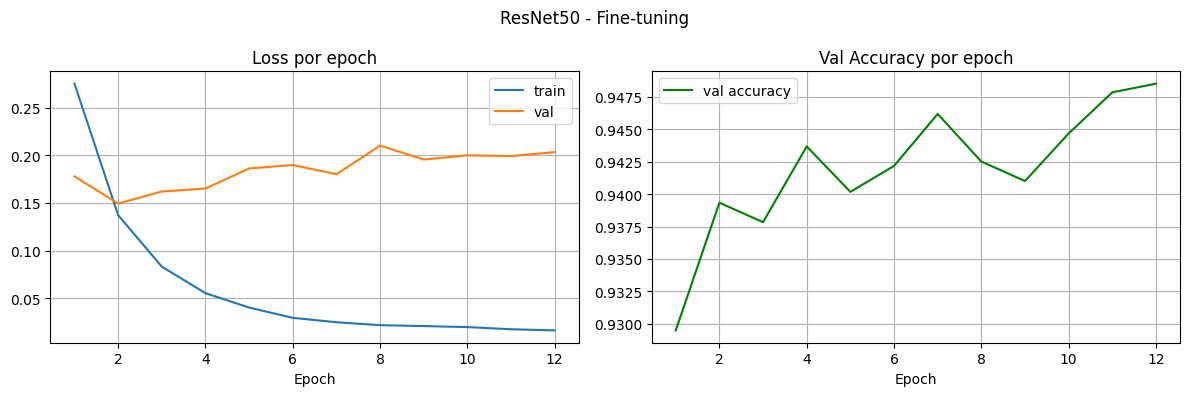

In [5]:
historial_ft = train_transfer(model_ft, save_name="ft", lr=1e-4)